In [2]:
import cv2
import numpy as np

## Basic Functions

In [3]:
def my_entropy(input_image):

    arr = input_image.flatten().astype(np.int64)

    if arr.min() != 1:
        arr = arr - arr.min() + 1

    p = np.zeros(arr.max(), dtype=np.float64)
    for v in arr:
        p[v - 1] += 1

    p = p / p.sum()
    p = p[p != 0]
    entropy = np.sum(-p * np.log2(p))

    return entropy

In [4]:
def next_power_of_two(x):
    return 1 << (x - 1).bit_length()

def peak_signal_noise_ratio(image1: np.ndarray, image2: np.ndarray):
    if image1.shape != image2.shape:
        return -1

    max_intensity = max(image1.max(), image2.max())

    next_pow2 = next_power_of_two(int(max_intensity + 1))
    max_value = next_pow2 - 1
    max_value_sq = max_value ** 2

    mse = np.mean((image1.astype(np.float64) - image2.astype(np.float64)) ** 2)

    if mse == 0:
        return np.inf

    return 10 * np.log10(max_value_sq / mse)

## Encoder

In [8]:
def encoder(left, right, block_size=16, search_range=22):
    """
    left  : reference image (H x W)
    right : current image (H x W)
    returns:
        motion_vectors : (H/block, W/block, 2)
        residual       : H x W
    """

    H, W = right.shape
    residual = np.zeros_like(right, dtype=np.int16)

    mv_h = H // block_size
    mv_w = W // block_size
    motion_vectors = np.zeros((mv_h, mv_w, 2), dtype=np.int16)

    for by in range(mv_h):
        for bx in range(mv_w):
            y = by * block_size
            x = bx * block_size

            curr_block = right[y:y+block_size, x:x+block_size]

            best_sad = np.inf
            best_mv = (0, 0)

            for dy in range(-search_range, search_range + 1):
                for dx in range(-search_range, search_range + 1):
                    ref_y = y + dy
                    ref_x = x + dx

                    if (ref_y < 0 or ref_x < 0 or
                            ref_y + block_size > H or
                            ref_x + block_size > W):
                        continue

                    ref_block = left[ref_y:ref_y+block_size,
                                ref_x:ref_x+block_size]

                    sad = np.sum(np.abs(curr_block.astype(np.int16) -
                                        ref_block.astype(np.int16)))

                    if sad < best_sad:
                        best_sad = sad
                        best_mv = (dy, dx)

            motion_vectors[by, bx] = best_mv

            ref_y = y + best_mv[0]
            ref_x = x + best_mv[1]
            pred_block = left[ref_y:ref_y+block_size,
                         ref_x:ref_x+block_size]

            residual[y:y+block_size, x:x+block_size] = (
                    curr_block.astype(np.int16) -
                    pred_block.astype(np.int16)
            )

    return motion_vectors, residual

## Decoder

In [9]:
def decoder(left, motion_vectors, residual, block_size=16):
    """
    left            : reference image
    motion_vectors  : (H/block, W/block, 2)
    residual        : H x W
    returns:
        reconstructed right image
    """

    H, W = left.shape
    recon = np.zeros_like(left, dtype=np.int16)

    mv_h, mv_w, _ = motion_vectors.shape

    for by in range(mv_h):
        for bx in range(mv_w):
            y = by * block_size
            x = bx * block_size

            dy, dx = motion_vectors[by, bx]

            ref_y = y + dy
            ref_x = x + dx

            pred_block = left[ref_y:ref_y+block_size,
                         ref_x:ref_x+block_size]

            recon[y:y+block_size, x:x+block_size] = (
                    pred_block.astype(np.int16) +
                    residual[y:y+block_size, x:x+block_size]
            )

    return recon


In [10]:
test_images = ['Alovera', 'Books', 'Bowling', 'Chess', 'Dolls', 'Snowman', 'Teddy']

for addr in test_images:
    left_image = cv2.imread(f'Stereo_Pairs/{addr}/Image_1.png', cv2.IMREAD_GRAYSCALE)
    right_image = cv2.imread(f'Stereo_Pairs/{addr}/Image_2.png', cv2.IMREAD_GRAYSCALE)

    motion_vectors, error = encoder(left=left_image, right=right_image)
    recon = decoder(left=left_image, motion_vectors=motion_vectors, residual=error)

    psnr = peak_signal_noise_ratio(image1=right_image, image2=recon)

    print(f'Test: {addr} - psnr:{psnr}')

Test: Alovera - psnr:18.26826145241967
Test: Books - psnr:17.624433496388853


KeyboardInterrupt: 

In [11]:
left_image = cv2.imread(f'Stereo_Pairs/Alovera/Image_1.png', cv2.IMREAD_GRAYSCALE)
right_image = cv2.imread(f'Stereo_Pairs/Alovera/Image_2.png', cv2.IMREAD_GRAYSCALE)

motion_vectors, error = encoder(left=left_image, right=right_image)
recon = decoder(left=left_image, motion_vectors=motion_vectors, residual=error)

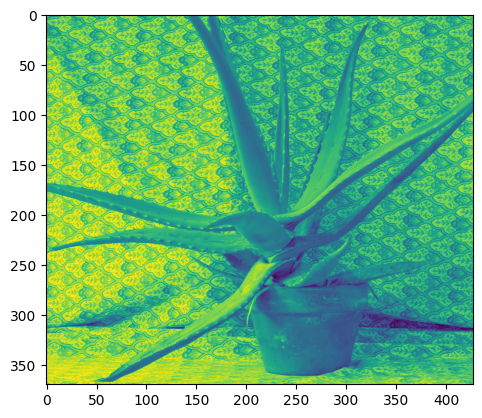

In [12]:
import matplotlib.pyplot as plt

plt.imshow(right_image)

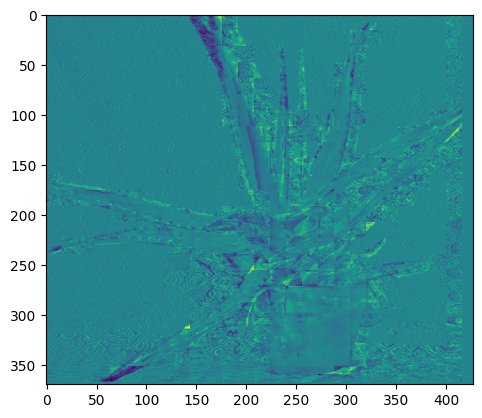

In [14]:
plt.imshow(error)